<a href="https://colab.research.google.com/github/mohadhil6238-a11y/House-fair-Prediction-gridsearchCV/blob/main/Copy_of_Bangaluru_House_Price_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#data understanding

In [82]:
import pandas as pd
import numpy as np

In [83]:
# Load the dfset
df = pd.read_csv('/content/Bengaluru_House_Data.csv')
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [84]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [85]:
df.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [86]:
df.dtypes


,0
area_type,object
availability,object
location,object
size,object
society,object
total_sqft,object
bath,float64
balcony,float64
price,float64


In [87]:
df.shape

(13320, 9)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [89]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [90]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [91]:
df.nunique()

,0
area_type,4
availability,81
location,1305
size,31
society,2688
total_sqft,2117
bath,19
balcony,4
price,1994


In [92]:
df['society'].unique()

array(['Coomee ', 'Theanmp', nan, ..., 'SJovest', 'ThhtsV ', 'RSntsAp'],
      dtype=object)

In [93]:
df['availability'].value_counts()

,count
availability,
Ready To Move,10581
18-Dec,307
18-May,295
18-Apr,271
18-Aug,200
...,...
16-Oct,1
17-Jan,1
16-Nov,1


In [94]:
df['society'].value_counts()

,count
society,
GrrvaGr,80
PrarePa,76
Sryalan,59
Prtates,59
GMown E,56
...,...
SLtalry,1
Rencyes,1
DiaveEn,1


In [95]:
df['location'].value_counts()

,count
location,
Whitefield,540
Sarjapur Road,399
Electronic City,302
Kanakpura Road,273
Thanisandra,234
...,...
3rd Stage Raja Rajeshwari Nagar,1
Chuchangatta Colony,1
"Electronic City Phase 1,",1


In [96]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


#data cleanning

In [97]:
df.groupby('total_sqft')['price'].mean()

,price
total_sqft,
1,120.000000
1.25Acres,200.000000
1.26Acres,125.000000
1000,64.611744
1000 - 1285,43.415000
...,...
995,39.694000
996,44.350000
997,54.000000


In [98]:
# axis = 1 for column operation, if it is 0, that for row
df.drop('society', axis=1, inplace=True)

In [99]:
# inplace = True for make the change on orginal data
df['bath'].fillna(df['bath'].median(), inplace=True)

/tmp/ipykernel_433/1552296698.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bath'].fillna(df['bath'].median(), inplace=True)


In [100]:
df['balcony'].fillna(df['balcony'].median(), inplace=True)

/tmp/ipykernel_433/2345094989.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['balcony'].fillna(df['balcony'].median(), inplace=True)


In [101]:
df['balcony']= df['balcony'].astype(int)

In [102]:
df['bath']= df['bath'].astype(int)

In [103]:
df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [104]:
def convert_sqft(x):
    try:
        if '-' in str(x):
            nums = x.split('-')
            return (float(nums[0]) + float(nums[1])) / 2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [105]:
df['total_sqft'].fillna(df['total_sqft'].median(),inplace=True)

/tmp/ipykernel_433/2789796240.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_sqft'].fillna(df['total_sqft'].median(),inplace=True)


In [106]:
df['total_sqft']= df['total_sqft'].astype(float)

In [107]:
df.dropna(subset=['location'],axis=0,inplace=True)

In [108]:
df['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [109]:
df['size'] = (df['size'].str.replace("Bedroom", "BHK", regex = None))

df['size'] = (df['size'].str.replace("RK", "BHK", regex = None))

df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2,1,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 BHK,2600.0,5,3,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2,3,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3,1,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2,1,51.00


In [110]:
df['size'].unique()

array(['2 BHK', '4 BHK', '3 BHK', '6 BHK', '1 BHK', '8 BHK', '7 BHK',
       '5 BHK', '11 BHK', '9 BHK', nan, '27 BHK', '10 BHK', '19 BHK',
       '16 BHK', '43 BHK', '14 BHK', '12 BHK', '13 BHK', '18 BHK'],
      dtype=object)

In [111]:
df.nunique()

,0
area_type,4
availability,81
location,1305
size,19
total_sqft,1999
bath,19
balcony,4
price,1994


In [112]:
df.dropna(subset=['size'],axis=0,inplace=True)

#categorical encoding

In [113]:

data = {'size' : ['1 BHK','2 BHK','3 BHK','4 BHK','5 BHK','6 BHK','7 BHK','8 BHK','9 BHK','10 BHK','11 BHK','12 BHK','13 BHK','14 BHK','16 BHK','18 BHK','19 BHK','27 BHK','43 BHK']}



data_mapping = {
    '1 BHK' : 1,
    '2 BHK' : 2,
    '3 BHK' : 3,
    '4 BHK' : 4,
    '5 BHK' : 5,
    '6 BHK' : 6,
    '7 BHK' : 7,
    '8 BHK' : 8,
    '9 BHK' : 9,
    '10 BHK' : 10,
    '11 BHK' : 11,
    '12 BHK' : 12,
    '13 BHK' : 13,
    '14 BHK' : 14,
    '16 BHK' : 15,
    '18 BHK' : 16,
    '19 BHK' : 17,
    '27 BHK' : 18,
    '43 BHK' : 19

}


In [114]:


df['size'] = df['size'].map(data_mapping)

df


,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2,1056.0,2,1,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4,2600.0,5,3,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,1440.0,2,3,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,1521.0,3,1,95.00
4,Super built-up Area,Ready To Move,Kothanur,2,1200.0,2,1,51.00
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5,3453.0,4,0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4,3600.0,5,2,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2,1141.0,2,1,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4,4689.0,4,1,488.00


In [115]:
df['area_type'].unique()

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [116]:
from sklearn.preprocessing import LabelEncoder

In [117]:
data = {'area_type':['Super built-up  Area', 'Plot  Area', 'Built-up  Area','Carpet  Area']}

le = LabelEncoder()

df['area_type']=le.fit_transform(df['area_type'])

df

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,3,19-Dec,Electronic City Phase II,2,1056.0,2,1,39.07
1,2,Ready To Move,Chikka Tirupathi,4,2600.0,5,3,120.00
2,0,Ready To Move,Uttarahalli,3,1440.0,2,3,62.00
3,3,Ready To Move,Lingadheeranahalli,3,1521.0,3,1,95.00
4,3,Ready To Move,Kothanur,2,1200.0,2,1,51.00
...,...,...,...,...,...,...,...,...
13315,0,Ready To Move,Whitefield,5,3453.0,4,0,231.00
13316,3,Ready To Move,Richards Town,4,3600.0,5,2,400.00
13317,0,Ready To Move,Raja Rajeshwari Nagar,2,1141.0,2,1,60.00
13318,3,18-Jun,Padmanabhanagar,4,4689.0,4,1,488.00


In [118]:
# axis = 1 for column operation, if it is 0, that for row
df.drop('availability', axis=1, inplace=True)

In [119]:
df.nunique()

,0
area_type,4
location,1304
size,19
total_sqft,1996
bath,19
balcony,4
price,1985


In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

#correlation matrix

In [121]:
c = df.corr(numeric_only=True)
c

,area_type,size,total_sqft,bath,balcony,price
area_type,1.000000,-0.127815,-0.049602,-0.101958,0.091587,-0.057410
size,-0.127815,1.000000,0.357630,0.881776,0.207259,0.409592
total_sqft,-0.049602,0.357630,1.000000,0.388139,0.154248,0.574794
bath,-0.101958,0.881776,0.388139,1.000000,0.208333,0.454691
balcony,0.091587,0.207259,0.154248,0.208333,1.000000,0.125093
price,-0.057410,0.409592,0.574794,0.454691,0.125093,1.000000


#plot heatmap

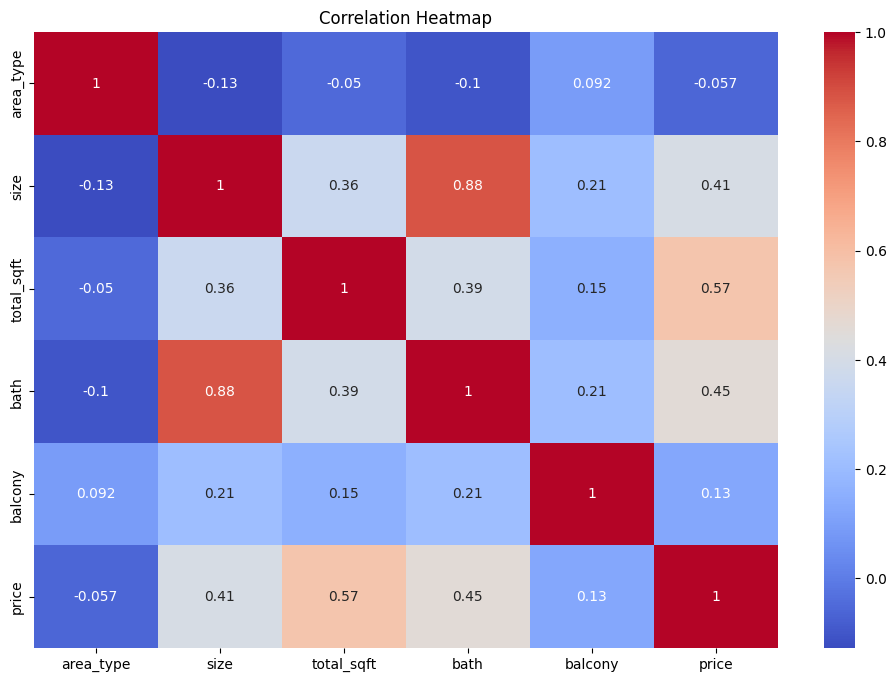

In [122]:
plt.figure(figsize=(12,8))
sns.heatmap(
    c,
    annot=True,
    cmap='coolwarm'
  )

plt.title( "Correlation Heatmap" )
plt.show()

In [123]:
#correlation with target variable

In [124]:
c['price'].sort_values(ascending=False)

,price
price,1.000000
total_sqft,0.574794
bath,0.454691
size,0.409592
balcony,0.125093
area_type,-0.057410


In [125]:
df

,area_type,location,size,total_sqft,bath,balcony,price
0,3,Electronic City Phase II,2,1056.0,2,1,39.07
1,2,Chikka Tirupathi,4,2600.0,5,3,120.00
2,0,Uttarahalli,3,1440.0,2,3,62.00
3,3,Lingadheeranahalli,3,1521.0,3,1,95.00
4,3,Kothanur,2,1200.0,2,1,51.00
...,...,...,...,...,...,...,...
13315,0,Whitefield,5,3453.0,4,0,231.00
13316,3,Richards Town,4,3600.0,5,2,400.00
13317,0,Raja Rajeshwari Nagar,2,1141.0,2,1,60.00
13318,3,Padmanabhanagar,4,4689.0,4,1,488.00


In [126]:
df.drop(['location','balcony'],axis=1,inplace = True)

#define features and target

In [127]:
X = df[['size','total_sqft','bath']]

In [128]:
y = df['price']

In [129]:
from sklearn.model_selection import train_test_split

In [130]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
      )
  )


In [131]:
X_train

,size,total_sqft,bath
11320,1,1276.0,1
8370,5,2400.0,3
5208,3,1460.0,2
9215,2,1224.0,2
9690,2,940.0,2
...,...,...,...
11981,7,3200.0,7
5197,4,900.0,4
5397,2,1312.0,2
862,2,1175.0,2


In [132]:
y_train

,price
11320,170.00
8370,80.00
5208,75.00
9215,45.00
9690,48.00
...,...
11981,150.00
5197,75.00
5397,55.00
862,51.47


In [133]:
from sklearn.linear_model import LinearRegression

In [134]:
df.isnull().sum()

,0
area_type,0
size,0
total_sqft,0
bath,0
price,0


In [135]:
model = LinearRegression()

model.fit( X_train, y_train )

LinearRegression()

In [136]:
print(df.isnull().sum())

area_type     0
size          0
total_sqft    0
bath          0
price         0
dtype: int64


In [137]:
y_pred = model.predict(
X_test
)

In [138]:
print(y_pred[:10])

[131.39282498 179.86285578  73.23834818  63.34312069  62.60467087
  66.05077    129.3743955   38.86894353  14.9854114  239.56496912]


In [139]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R-squared:", r2)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

R-squared: 0.5045497402841652
Mean Absolute Error: 46.08400663722749
Mean Squared Error: 12204.752706686326


In [140]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(f'RMSE: {rmse}')

RMSE: 110.4751225692297


In [141]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Initialize the models in a dictionary for easy iteration
models = {
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Support Vector Regressor": SVR(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

# 2. Loop through each model, train, predict, and evaluate
for name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Print the evaluation block for the current model
    print(f"=== {name} Evaluation Results ===")
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"MSE      : {mse:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print("-" * 40)

=== Decision Tree Evaluation Results ===
R² Score : 0.4997
MAE      : 40.2133
MSE      : 12325.2620
RMSE     : 111.0192
----------------------------------------
=== Random Forest Evaluation Results ===
R² Score : 0.6212
MAE      : 38.1655
MSE      : 9331.3476
RMSE     : 96.5989
----------------------------------------
=== Support Vector Regressor Evaluation Results ===
R² Score : 0.2902
MAE      : 44.3075
MSE      : 17484.1639
RMSE     : 132.2277
----------------------------------------
=== K-Neighbors Regressor Evaluation Results ===
R² Score : 0.6013
MAE      : 39.2593
MSE      : 9821.1399
RMSE     : 99.1017
----------------------------------------
=== Gradient Boosting Evaluation Results ===
R² Score : 0.6193
MAE      : 38.8619
MSE      : 9378.1821
RMSE     : 96.8410
----------------------------------------


In [142]:
from sklearn.model_selection import GridSearchCV

In [143]:
params = {
    'n_estimators': [100,200,300],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,4,5]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    params,
    cv=5,
    scoring = 'r2'
)
grid.fit(X_train,y_train)


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [144]:
print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
0.44132854329391363


In [145]:
model6=GradientBoostingRegressor(learning_rate=0.01,max_depth=5,n_estimators=200,random_state=42)

model6.fit(X_train,y_train)

y_pred=model6.predict(X_test)
y_pred

array([115.64612608, 176.06306413,  72.6383635 , ..., 223.28542352,
        72.6383635 ,  53.55030523])

In [146]:
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

In [147]:
print(r2)
print(mae)
print(mse)
print(rmse)

0.6337126196052012
39.254755378371485
9022.998393143416
94.98946464289298


In [148]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import ( r2_score, mean_absolute_error, mean_squared_error )

In [149]:
params = { 'n_estimators': [100, 200, 300, 400],
          'learning_rate': [0.01, 0.05, 0.1],
          'max_depth': [3, 4, 5],
          'min_samples_split': [2, 5, 10],
          'min_samples_leaf': [1, 2, 4],
          'subsample': [0.6, 0.8, 1.0] }

In [150]:
random_search = RandomizedSearchCV( estimator=GradientBoostingRegressor(random_state=42),
                                    param_distributions=params, n_iter=20, cv=5,
                                    scoring='r2',
                                    random_state=42,
                                    n_jobs=-1 )

In [151]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='r2')

In [152]:
print("Best Parameters:")
print(random_search.best_params_)
print("\nBest Cross Validation Score:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.01}

Best Cross Validation Score:
0.4973275660867945


In [153]:
model7 = GradientBoostingRegressor( learning_rate=0.01,
                                    max_depth=5,
                                    n_estimators=300,
                                    min_samples_split=5,
                                    min_samples_leaf=4,
                                    subsample=0.8,
                                    random_state=42 )

In [154]:
model7.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, max_depth=5, min_samples_leaf=4,
                          min_samples_split=5, n_estimators=300,
                          random_state=42, subsample=0.8)

In [158]:
pred7 = model7.predict(X_test)
print("\nPredictions:")
print(pred7)


Predictions:
[116.13994946 180.69993488  67.7710439  ... 238.38413538  67.7710439
  48.44991865]


In [159]:
r2 = r2_score(y_test, pred7)
mae = mean_absolute_error(y_test, pred7)
mse = mean_squared_error(y_test, pred7)
rmse = np.sqrt(mse)

In [160]:
print("\nModel Performance")
print("----------------------------")
print("R² Score :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)


Model Performance
----------------------------
R² Score : 0.6522784695315984
MAE : 38.416811586779005
MSE : 8565.653578608268
RMSE : 92.5508161963376


In [163]:
import pickle as pkl
pkl.dump(model7, open('model7.pkl', 'wb'))

In [164]:

pkl.load(open('model7.pkl', 'rb'))

GradientBoostingRegressor(learning_rate=0.01, max_depth=5, min_samples_leaf=4,
                          min_samples_split=5, n_estimators=300,
                          random_state=42, subsample=0.8)